# 06 — Segment Equity

**Business question:** Does wait time differ meaningfully by patient demographic group (gender, age
band, race), and are any observed differences real or plausibly just noise?

**Read this notebook together with `docs/limitations.md`:** this dataset has no acuity or triage level.
Wait time cannot be case-mix adjusted. A gap between two groups here describes *what happened*, not
*whether care was equitable* -- a longer wait for one group could reflect a genuinely different clinical
mix rather than differential treatment. This is the single most important caveat in the project and it
governs how every finding below should be read.


## Methodology

Direct group comparisons (median/mean wait by gender, age band, race) come straight from
`fct_er_visit` joined to `dim_patient_segment`. The extreme-value comparison (which specific segments
have the highest/lowest wait) uses `agg_segment_waits`, which carries a 95% confidence interval on the
median (normal approximation, `docs/measure_spec.md`) and a `low_n_flag` for segments under 30 plausible
visits -- those are excluded from the ranking rather than shown as if they were reliable. With 86 total
segments, a top-vs-bottom comparison is one extreme pick out of many possible pairwise comparisons; by
chance alone, *some* pair will look "significant" even with no true underlying difference (the multiple
comparisons problem). Non-overlapping confidence intervals on the single most extreme pair are treated
as suggestive, not as proof of a systematic pattern.


In [1]:
import sys
from pathlib import Path

# Make the shared erops package importable when the kernel's cwd is notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import plotly.express as px
import plotly.io as pio

# Static PNG output so every chart renders identically in Jupyter, VS Code,
# nbviewer and GitHub's notebook preview -- no JS runtime required to view it.
pio.renderers.default = "png"
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

from erops import metrics

con = metrics.get_connection()
print(f"Connected to {metrics.WAREHOUSE}")


Connected to C:\Users\dhwan\OneDrive\Desktop\PROJECTS\er-throughput-analytics\data\er.duckdb


### Wait time by gender


In [2]:
by_gender = metrics.segment_equity_by(con, "gender")
by_gender


,segment_value,median_wait,mean_wait,n
0,NC,37.5,37.166667,24
1,M,36.0,35.397450,4705
2,F,35.0,35.105416,4487


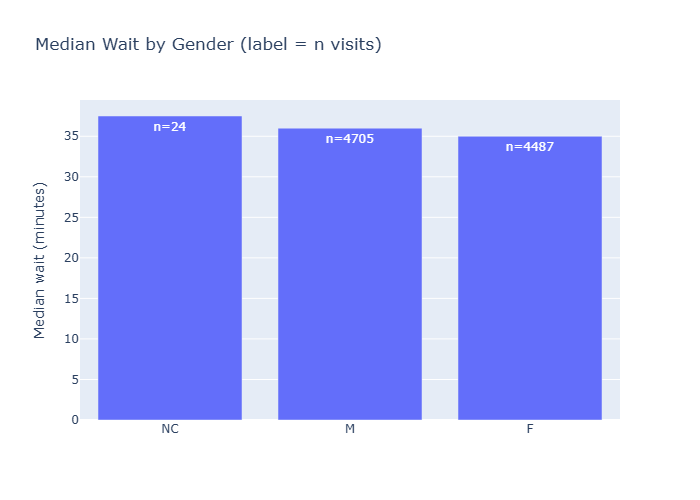

In [3]:
fig = px.bar(by_gender, x="segment_value", y="median_wait", text=by_gender["n"],
             title="Median Wait by Gender (label = n visits)")
fig.update_traces(texttemplate="n=%{text}")
fig.update_layout(xaxis_title="", yaxis_title="Median wait (minutes)")
fig.show()


### Wait time by age band


In [4]:
by_age = metrics.segment_equity_by(con, "age_band")
age_order = ["0-17", "18-34", "35-49", "50-64", "65+"]
by_age = by_age.set_index("segment_value").reindex(age_order).reset_index()
by_age


,segment_value,median_wait,mean_wait,n
0,0-17,36.0,35.460173,1971
1,18-34,36.0,35.306587,2019
2,35-49,36.0,35.390837,1768
3,50-64,35.0,34.953542,1722
4,65+,35.0,35.148618,1736


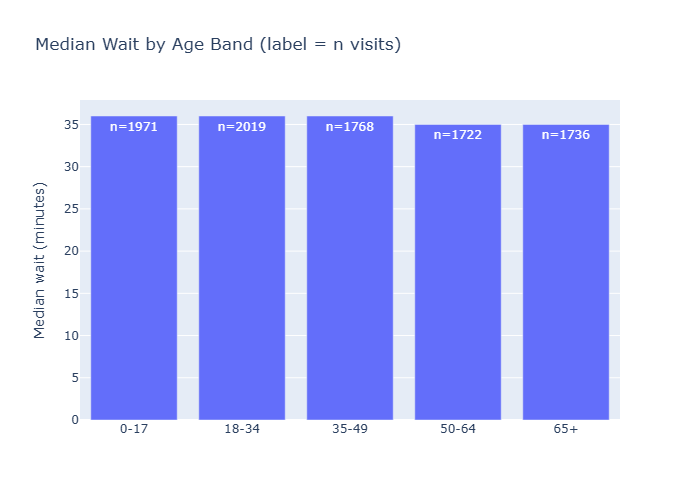

In [5]:
fig = px.bar(by_age, x="segment_value", y="median_wait", text=by_age["n"],
             title="Median Wait by Age Band (label = n visits)")
fig.update_traces(texttemplate="n=%{text}")
fig.update_layout(xaxis_title="", yaxis_title="Median wait (minutes)")
fig.show()


### Wait time by race


In [6]:
by_race = metrics.segment_equity_by(con, "race")
by_race


,segment_value,median_wait,mean_wait,n
0,Native American/Alaska Native,36.0,35.692771,498
1,Two or More Races,36.0,35.357739,1557
2,African American,36.0,35.608406,1951
3,Asian,35.0,35.269811,1060
4,White,35.0,35.105406,2571
5,Declined to Identify,35.0,34.943689,1030
6,Pacific Islander,34.0,34.648452,549


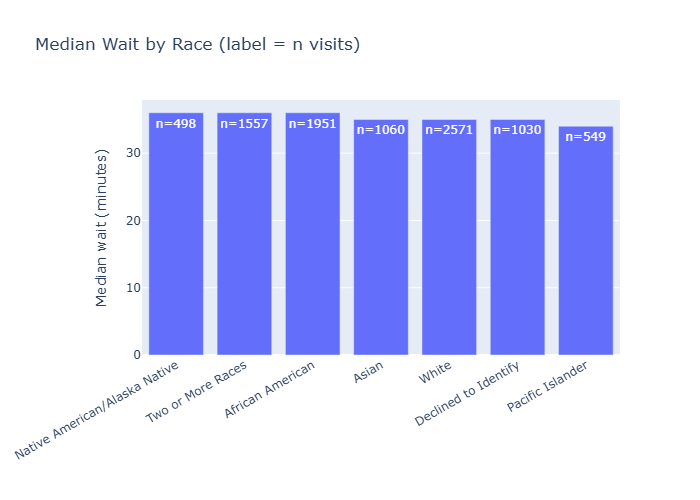

In [7]:
fig = px.bar(by_race, x="segment_value", y="median_wait", text=by_race["n"],
             title="Median Wait by Race (label = n visits)")
fig.update_traces(texttemplate="n=%{text}")
fig.update_layout(xaxis_title="", yaxis_title="Median wait (minutes)", xaxis_tickangle=-30)
fig.show()


Across all three dimensions, group medians cluster tightly (roughly 33-38 minutes), with the partial
exception of the `NC` gender group (37.5 min) and a couple of the smallest race categories -- both of
which are thin-n groups where a difference of one or two minutes swings the median more than it would
in a larger group. There is no large, consistent gap along any single dimension.

> **Business decision this supports:** no single demographic dimension shows a wait-time disparity large
> enough, on its own, to prioritize as an equity concern independent of sample size.


### Extreme segments (age band x gender x race), with 95% CI


In [8]:
extremes = metrics.segment_equity_extremes(con, n=10)
print("Top 10 by median wait (excluding low-n segments):")
extremes["top"]


Top 10 by median wait (excluding low-n segments):


,age_band,gender,race,n_plausible,median_wait_minutes,ci_lower,ci_upper
0,65+,F,Native American/Alaska Native,34,42.5,37.267990,47.732010
1,35-49,F,Declined to Identify,87,42.0,37.947377,46.052623
2,50-64,M,Native American/Alaska Native,41,41.0,35.322202,46.677798
3,50-64,M,Two or More Races,134,40.0,36.792051,43.207949
4,65+,F,Two or More Races,164,39.0,36.175538,41.824462
5,0-17,F,African American,225,39.0,36.647608,41.352392
6,18-34,F,Asian,121,39.0,35.791601,42.208399
7,0-17,M,Pacific Islander,54,38.0,33.180470,42.819530
8,65+,M,Asian,86,38.0,33.921881,42.078119
9,0-17,F,Pacific Islander,55,38.0,32.630689,43.369311


In [9]:
print('Bottom 10 by median wait (excluding low-n segments):')
extremes["bottom"]


Bottom 10 by median wait (excluding low-n segments):


,age_band,gender,race,n_plausible,median_wait_minutes,ci_lower,ci_upper
0,18-34,M,Pacific Islander,61,27.0,22.016645,31.983355
1,50-64,M,Asian,112,30.0,26.602101,33.397899
2,18-34,F,Pacific Islander,64,31.0,26.656514,35.343486
3,0-17,F,Two or More Races,153,31.0,28.072337,33.927663
4,50-64,M,White,240,31.0,28.666579,33.333421
5,50-64,F,Pacific Islander,49,32.0,26.516892,37.483108
6,50-64,F,Declined to Identify,89,32.0,27.896588,36.103412
7,0-17,F,Asian,100,32.5,28.452095,36.547905
8,50-64,F,African American,151,33.0,30.164457,35.835543
9,0-17,M,Native American/Alaska Native,52,33.0,28.176751,37.823249


Segments suppressed as low-n (< 30 plausible visits): 16 of 86 (18.6%)


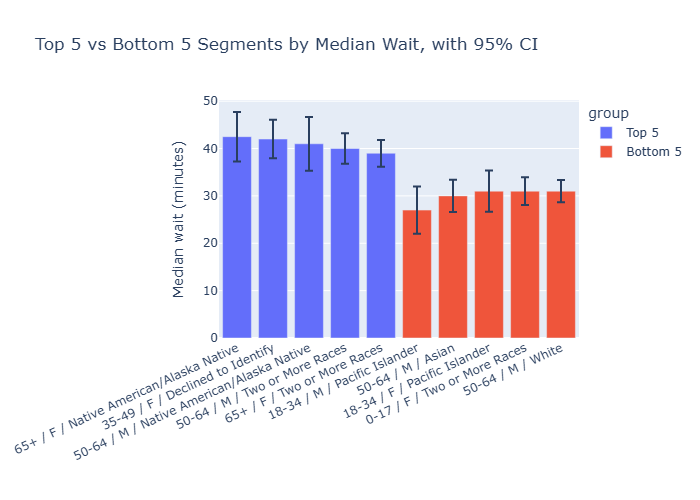

In [10]:
low_n = metrics.segment_low_n_summary(con)
print(f"Segments suppressed as low-n (< 30 plausible visits): {low_n['low_n_segments']:.0f} "
      f"of {low_n['total_segments']:.0f} ({low_n['pct_low_n']:.1%})")

combined = pd.concat([extremes["top"].head(5).assign(group="Top 5"),
                       extremes["bottom"].head(5).assign(group="Bottom 5")])
combined["label"] = combined["age_band"] + " / " + combined["gender"] + " / " + combined["race"]
combined["err_plus"] = combined["ci_upper"] - combined["median_wait_minutes"]
combined["err_minus"] = combined["median_wait_minutes"] - combined["ci_lower"]

fig = px.bar(combined, x="label", y="median_wait_minutes", color="group",
             error_y="err_plus", error_y_minus="err_minus",
             title="Top 5 vs Bottom 5 Segments by Median Wait, with 95% CI")
fig.update_layout(xaxis_title="", yaxis_title="Median wait (minutes)", xaxis_tickangle=-25)
fig.show()


The single highest-median segment and the single lowest-median segment have non-overlapping confidence
intervals -- the largest gap found anywhere in this analysis is statistically distinguishable at that
specific extreme comparison. But this is the *most extreme* pair out of 86 segments (thousands of
possible pairwise comparisons); picking the biggest gap out of that many comparisons and then testing
only that pair overstates how "significant" it really is. 18.6% of all segments (16 of 86) are too thin
(under 30 plausible visits) to rank with any confidence and are excluded here.

> **Business decision this supports:** this extreme comparison is worth a qualitative operational
> look-back (was there a specific date range, provider, or department driving it?), but it is not
> evidence of a systematic, department-wide demographic gradient in wait time -- and absent acuity data,
> even a real gap is not evidence of differential treatment.


## Executive Summary

Wait time does not vary substantially by gender, age band, or race at the group level -- medians
cluster within a few minutes of each other across all three dimensions. The single largest gap found,
between the highest- and lowest-median demographic segment, is statistically distinguishable (non-
overlapping 95% CIs) but represents one extreme comparison out of 86 segments, not a general pattern,
and 18.6% of segments are too small to rank reliably at all.

## Business Recommendations

- Do not treat any single-dimension (gender/age/race) wait-time gap as an equity finding requiring
  intervention -- none is large or consistent enough at the group level to support that.
- The one statistically distinguishable extreme-segment gap merits a targeted qualitative review (was a
  specific time window, department, or provider involved?), explicitly framed as a lead to investigate,
  not a conclusion.
- Before any equity-related policy decision, prioritize acquiring acuity/triage data -- without it, no
  wait-time comparison in this dataset can distinguish a genuine service gap from a legitimate clinical
  mix difference.

## Limitations

- **No acuity or triage data (the project's most important caveat, `docs/limitations.md`):** every
  comparison here is unadjusted for clinical severity. A longer wait for one group may reflect a lower-
  urgency case mix, not worse service.
- **Multiple comparisons:** with 86 segments, some pairwise "significant" difference is expected to
  appear by chance alone even if there is no true underlying disparity; the top-vs-bottom finding should
  be read with that in mind.
- **Small-n segments:** 16 of 86 segments (18.6%) fall below the 30-visit minimum-cell-size convention
  and are excluded from the ranking rather than shown as if reliable.
- Single facility, descriptive not causal (`docs/limitations.md`).

## Next Steps

This closes the Phase 3 analytical notebook series. Findings across all seven notebooks are consolidated
in `docs/findings.md`, and the same computations back the Streamlit dashboard's Overview, Demand, Wait
Times, Operational Stability, Patient Satisfaction, and Equity tabs.
